In [1]:
import numpy as np
import tables_io

import matplotlib.pyplot as plt
plt.style.use("/global/homes/s/sajkov/umap_nz_cal.mplstyle")

In [2]:
outputs_directory = "/pscratch/sd/s/sajkov/analysis_pipeline/runs/06Jul26"

In [3]:
REDSHIFTS_WideFastDeep = np.load(f"{outputs_directory}/TRUEREDSHIFTS_WideFastDeep.pkl.npy")
PHOTOZS_estimated_wSpecZs = tables_io.read(f"{outputs_directory}/estimatedPhotoZMedians_UMAP_wSpecZs_06Jul26.pq")
PHOTOZS_estimated_wPhotoZs = tables_io.read(f"{outputs_directory}/estimatedPhotoZMedians_UMAP_wPhotoZs_06Jul26.pq")

column_list None
column_list None


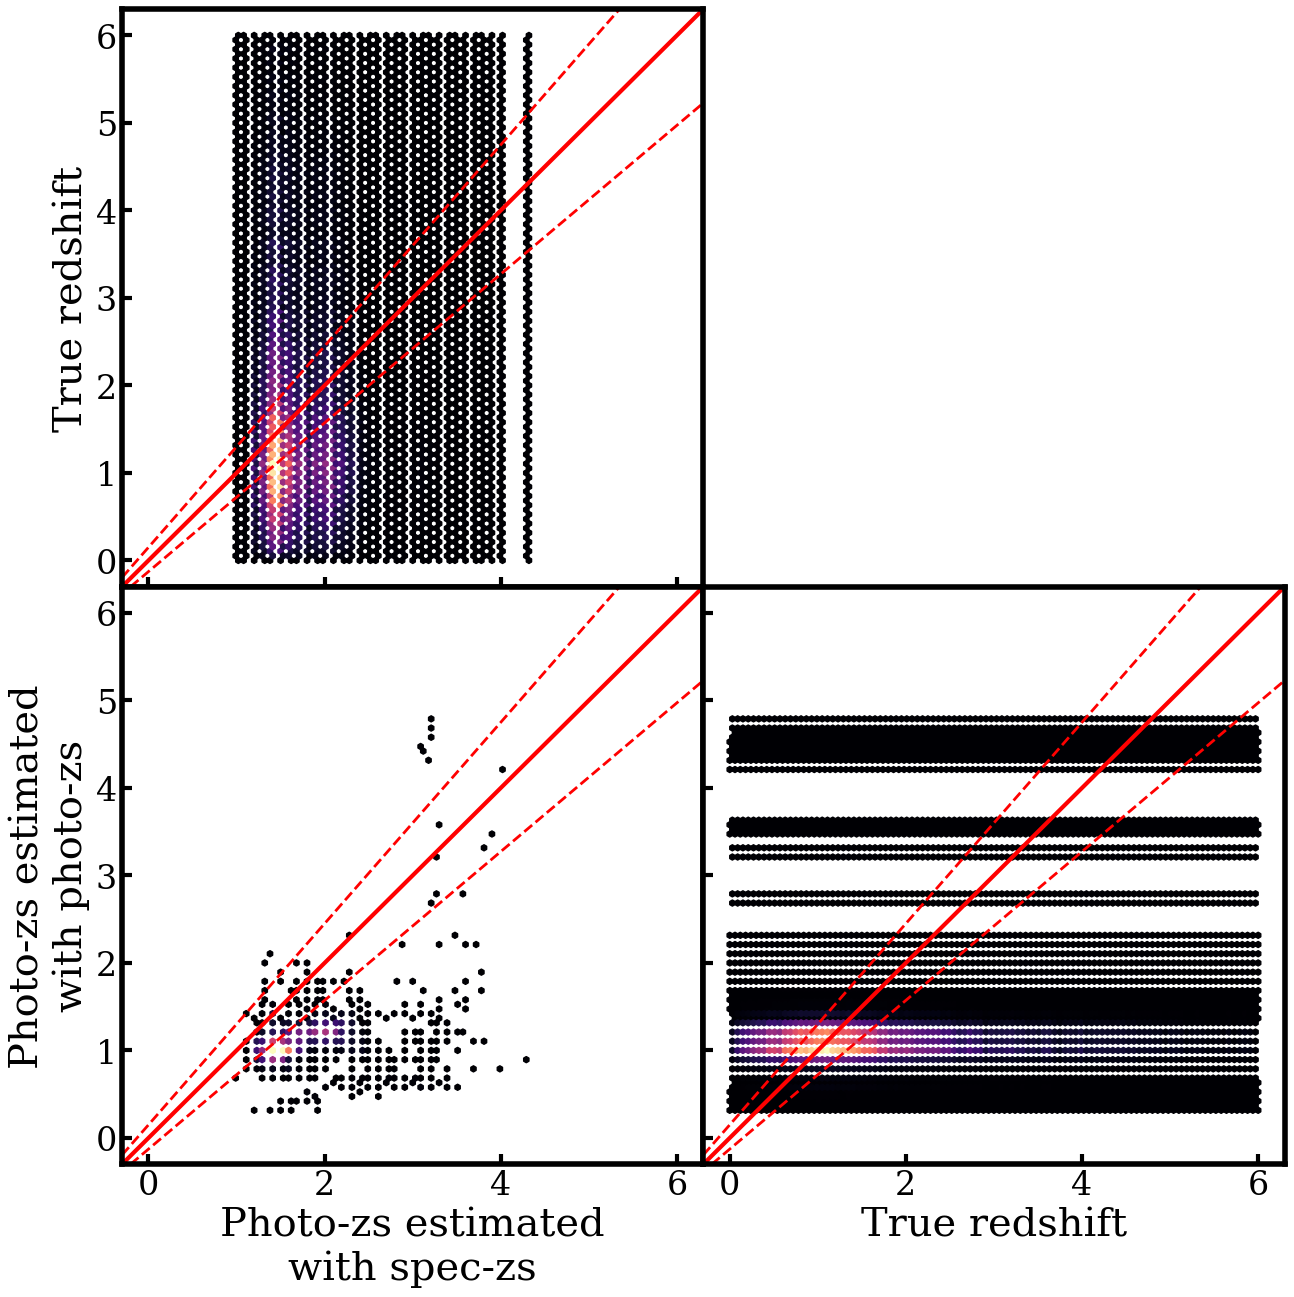

In [6]:
fig = plt.figure(figsize = (15, 15))
axs = fig.subplots(2, 2, sharex = True, sharey = True)

hexbin_props = dict(
    mincnt = 1,
    extent = [0, 6, 0, 6]
)

ax_bl = axs[1, 0]
ax_bl.hexbin(PHOTOZS_estimated_wSpecZs, PHOTOZS_estimated_wPhotoZs, **hexbin_props)
ax_bl.set_xlabel("Photo-zs estimated\nwith spec-zs")
ax_bl.set_ylabel("Photo-zs estimated\nwith photo-zs")
ax_bl.axline((0, 0), slope = 1, color = "red")
ax_bl.axline((0, .15), slope = 1.15, color = "red", linestyle = "--", linewidth = 2)
ax_bl.axline((.15, 0), slope = .85, color = "red", linestyle = "--", linewidth = 2)


ax_tl = axs[0, 0]
ax_tl.hexbin(PHOTOZS_estimated_wSpecZs, REDSHIFTS_WideFastDeep, **hexbin_props)
ax_tl.set_ylabel("True redshift")
ax_tl.axline((0, 0), slope = 1, color = "red")
ax_tl.axline((0, .15), slope = 1.15, color = "red", linestyle = "--", linewidth = 2)
ax_tl.axline((.15, 0), slope = .85, color = "red", linestyle = "--", linewidth = 2)

ax_br = axs[1, 1]
ax_br.hexbin(REDSHIFTS_WideFastDeep, PHOTOZS_estimated_wPhotoZs, **hexbin_props)
ax_br.set_xlabel("True redshift")
ax_br.axline((0, 0), slope = 1, color = "red")
ax_br.axline((0, .15), slope = 1.15, color = "red", linestyle = "--", linewidth = 2)
ax_br.axline((.15, 0), slope = .85, color = "red", linestyle = "--", linewidth = 2)

axs[0, 1].remove()

fig.subplots_adjust(hspace = 0, wspace = 0)
fig.savefig(f"{outputs_directory}/comparison_plot.png", dpi = 150, bbox_inches = "tight")